  # 01 — Initial Functional Exploration of Gaia XP Sampled Spectra



  This notebook performs an initial functional data exploration of sampled

  Gaia XP spectra for the binary vs non-binary classification task.



  Main goals:

  - inspect the structure and quality of the sampled spectra data

  - visualize example spectra

  - compute functional mean and standard deviation curves

  - compare class-wise mean spectra

  - inspect mean difference curves between classes

  - explore correlation structure across wavelengths

  - examine first and second derivatives of spectra



  The notebook is descriptive and exploratory only.

  No predictive models are trained here.



  Data:

  - sampled spectra from `xp_sampled_spectra.csv`

  - labels from the same file if available, otherwise from `og_xp.csv`



  Main exported outputs:

  - dataset_summary.csv

  - class_mean_spectra.csv

  - derivative_summary_by_class.csv

  - top_wavelength_differences.csv

  - spectrum_descriptors.csv

  - fig_example_spectra.svg

  - fig_mean_std_overall.svg

  - fig_class_mean_spectra.svg

  - fig_class_mean_difference_l2.svg

  - fig_correlation_heatmap.svg

  - fig_first_derivative_means.svg

  - fig_second_derivative_means.svg

In [17]:
from __future__ import annotations

import warnings
from datetime import datetime
from pathlib import Path
from typing import List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


  ## 1. Configuration

In [18]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "01_initial_data_exploration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")

SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

# Which representation to use for the main plots / derivatives / correlation:
# "raw" or "l2"
MAIN_REPRESENTATION = "l2"

N_EXAMPLE_PER_CLASS = 8
CORR_PLOT_STEP = 3


  ## 2. Plot style for thesis-ready figures

In [ ]:
COLOR_PRIMARY = "#104A7E"     
COLOR_SECONDARY = "#78003F"  

COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


  ## 3. Helper functions

In [20]:
def find_first_existing(paths: Sequence[Path]) -> Optional[Path]:
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def detect_id_column(df: pd.DataFrame) -> str:
    candidates = ["source_id", "SOURCE_ID", "id", "ID"]
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError("Could not find an ID column such as `source_id`.")


def detect_label_column(df: pd.DataFrame) -> Optional[str]:
    candidates = [
        "y", "label", "target", "class", "binary_label",
        "is_binary", "binary", "labels"
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None


def coerce_binary_labels(series: pd.Series) -> pd.Series:
    s = series.copy()

    if pd.api.types.is_numeric_dtype(s):
        vals = sorted(pd.Series(s).dropna().unique().tolist())
        if set(vals).issubset({0, 1}):
            return s.astype(int)

    s_str = s.astype(str).str.strip().str.lower()
    mapping = {
        "0": 0,
        "1": 1,
        "false": 0,
        "true": 1,
        "non-binary": 0,
        "non_binary": 0,
        "nonbinary": 0,
        "binary": 1,
        "single": 0,
    }
    mapped = s_str.map(mapping)

    if mapped.isna().any():
        uniques = sorted(s_str.dropna().unique().tolist())
        if len(uniques) != 2:
            raise ValueError(
                f"Could not safely coerce labels to binary. Unique values: {uniques}"
            )
        fallback_map = {uniques[0]: 0, uniques[1]: 1}
        mapped = s_str.map(fallback_map)

    return mapped.astype(int)


def detect_flux_columns(df: pd.DataFrame) -> List[str]:
    cols = list(df.columns)

    wl_style = [c for c in cols if str(c).startswith("wl_")]
    if wl_style:
        return sorted(wl_style, key=lambda x: float(str(x).replace("wl_", "")))

    flux_style = [c for c in cols if str(c).startswith("flux_")]
    if flux_style:
        def flux_key(name: str) -> int:
            try:
                return int(str(name).replace("flux_", ""))
            except ValueError:
                return 10**9
        return sorted(flux_style, key=flux_key)

    raise ValueError("Could not find spectral columns like `wl_336` or `flux_0`.")


def build_wavelength_axis(flux_cols: Sequence[str]) -> np.ndarray:
    if all(str(c).startswith("wl_") for c in flux_cols):
        return np.array([float(str(c).replace("wl_", "")) for c in flux_cols], dtype=float)

    if all(str(c).startswith("flux_") for c in flux_cols):
        return np.arange(len(flux_cols), dtype=float)

    raise ValueError("Could not build wavelength axis.")


def l2_row_normalize(X: np.ndarray, eps: float = 1e-20) -> np.ndarray:
    row_norm = np.linalg.norm(X, axis=1, keepdims=True)
    return np.divide(X, row_norm, out=np.zeros_like(X), where=row_norm > eps)


def compute_first_derivative(X: np.ndarray, wavelengths: np.ndarray) -> np.ndarray:
    return np.gradient(X, wavelengths, axis=1)


def compute_second_derivative(X: np.ndarray, wavelengths: np.ndarray) -> np.ndarray:
    d1 = np.gradient(X, wavelengths, axis=1)
    d2 = np.gradient(d1, wavelengths, axis=1)
    return d2


  ## 4. Load and prepare data

In [21]:
sampled_path = find_first_existing(SAMPLED_CANDIDATES)
label_path = find_first_existing(LABEL_CANDIDATES)

if sampled_path is None:
    raise FileNotFoundError("Could not find `xp_sampled_spectra.csv`.")

print("Sampled spectra file:", sampled_path)
print("Label file:", label_path if label_path is not None else "not needed / not found")

sampled_df = pd.read_csv(sampled_path)
print("Loaded sampled_df shape:", sampled_df.shape)

sampled_id_col = detect_id_column(sampled_df)
sampled_label_col = detect_label_column(sampled_df)
flux_cols = detect_flux_columns(sampled_df)

print("ID column:", sampled_id_col)
print("Label column in sampled file:", sampled_label_col)
print("Number of spectral columns:", len(flux_cols))
print("First 5 spectral columns:", flux_cols[:5])

if sampled_label_col is not None:
    work_df = sampled_df[[sampled_id_col, sampled_label_col] + flux_cols].copy()
    work_df = work_df.rename(columns={sampled_id_col: "source_id", sampled_label_col: "y"})
else:
    if label_path is None:
        raise FileNotFoundError(
            "No label column found in sampled spectra file and no label file available."
        )

    label_df = pd.read_csv(label_path)
    label_id_col = detect_id_column(label_df)
    label_col = detect_label_column(label_df)

    if label_col is None:
        raise ValueError("Could not find a label column in label file.")

    label_df = label_df[[label_id_col, label_col]].copy()
    label_df = label_df.rename(columns={label_id_col: "source_id", label_col: "y"})

    work_df = sampled_df[[sampled_id_col] + flux_cols].copy()
    work_df = work_df.rename(columns={sampled_id_col: "source_id"})
    work_df = work_df.merge(label_df, on="source_id", how="inner")

work_df = work_df.dropna(subset=["y"]).copy()
work_df["y"] = coerce_binary_labels(work_df["y"])

before = len(work_df)
work_df = work_df.dropna(subset=flux_cols).reset_index(drop=True)
after = len(work_df)

print(f"Dropped rows with missing labels/spectra: {before - after}")
print("Final dataset shape:", work_df.shape)
print("\nClass counts:")
print(work_df["y"].value_counts().sort_index())

X_raw = work_df[flux_cols].to_numpy(dtype=np.float64)
y = work_df["y"].to_numpy(dtype=np.int64)
source_ids = work_df["source_id"].to_numpy()
wavelengths = build_wavelength_axis(flux_cols)

X_l2 = l2_row_normalize(X_raw)

if MAIN_REPRESENTATION == "l2":
    X_main = X_l2.copy()
elif MAIN_REPRESENTATION == "raw":
    X_main = X_raw.copy()
else:
    raise ValueError("MAIN_REPRESENTATION must be 'raw' or 'l2'.")

print("X_raw shape:", X_raw.shape)
print("X_l2 shape:", X_l2.shape)
print("Main representation:", MAIN_REPRESENTATION)
print("Wavelength axis length:", len(wavelengths))
print("Wavelength range:", float(wavelengths.min()), "to", float(wavelengths.max()))


Sampled spectra file: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv
Label file: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
Loaded sampled_df shape: (2815, 345)
ID column: source_id
Label column in sampled file: y
Number of spectral columns: 343
First 5 spectral columns: ['wl_336', 'wl_338', 'wl_340', 'wl_342', 'wl_344']
Dropped rows with missing labels/spectra: 0
Final dataset shape: (2815, 345)

Class counts:
y
0    2257
1     558
Name: count, dtype: int64
X_raw shape: (2815, 343)
X_l2 shape: (2815, 343)
Main representation: l2
Wavelength axis length: 343
Wavelength range: 336.0 to 1020.0


  ## 5. Basic dataset summary

In [22]:
dataset_summary = pd.DataFrame({
    "timestamp": [TIMESTAMP],
    "n_objects": [len(work_df)],
    "n_features": [X_main.shape[1]],
    "n_binary": [int(np.sum(y == 1))],
    "n_non_binary": [int(np.sum(y == 0))],
    "main_representation": [MAIN_REPRESENTATION],
    "wavelength_min": [float(wavelengths.min())],
    "wavelength_max": [float(wavelengths.max())],
})

class_balance = (
    pd.Series(y)
    .map({0: "nedvinarė", 1: "dvinarė"})
    .value_counts()
    .rename_axis("klasė")
    .reset_index(name="kiekis")
)
class_balance["dalis"] = class_balance["kiekis"] / class_balance["kiekis"].sum()

display(dataset_summary)
display(class_balance)


,timestamp,n_objects,n_features,n_binary,n_non_binary,main_representation,wavelength_min,wavelength_max
0,20260426_1438,2815,343,558,2257,l2,336.0,1020.0


,klasė,kiekis,dalis
0,nedvinarė,2257,0.801776
1,dvinarė,558,0.198224


  ## 6. Example spectra by class

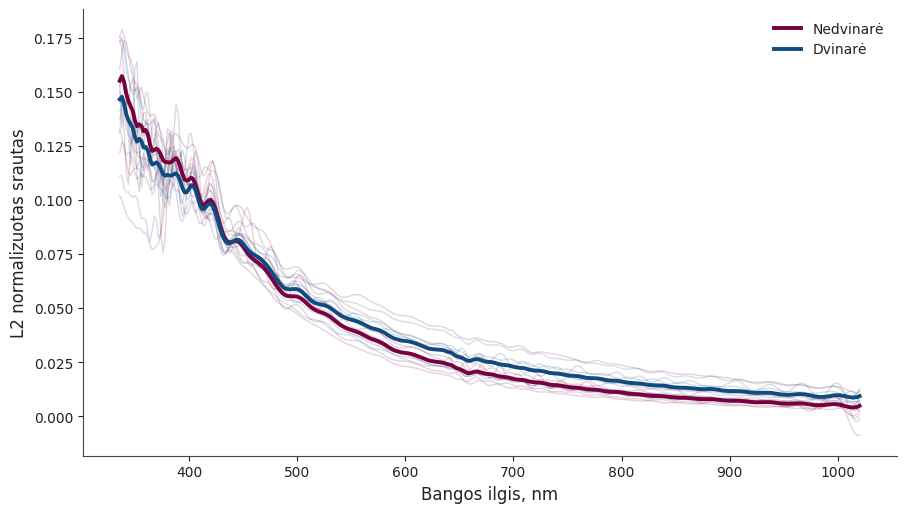

In [23]:
idx_binary = np.where(y == 1)[0]
idx_nonbinary = np.where(y == 0)[0]

rng = np.random.default_rng(RANDOM_STATE)
plot_binary = rng.choice(idx_binary, size=min(N_EXAMPLE_PER_CLASS, len(idx_binary)), replace=False)
plot_nonbinary = rng.choice(idx_nonbinary, size=min(N_EXAMPLE_PER_CLASS, len(idx_nonbinary)), replace=False)

mean_binary_main = X_main[idx_binary].mean(axis=0)
mean_nonbinary_main = X_main[idx_nonbinary].mean(axis=0)

mean_binary_raw = X_raw[idx_binary].mean(axis=0)
mean_nonbinary_raw = X_raw[idx_nonbinary].mean(axis=0)

mean_binary_l2 = X_l2[idx_binary].mean(axis=0)
mean_nonbinary_l2 = X_l2[idx_nonbinary].mean(axis=0)
diff_l2 = mean_binary_l2 - mean_nonbinary_l2

fig, ax = plt.subplots(figsize=(10.5, 5.8))

for idx in plot_nonbinary:
    ax.plot(wavelengths, X_main[idx], alpha=0.18, linewidth=1.0, color=COLOR_SECONDARY)
for idx in plot_binary:
    ax.plot(wavelengths, X_main[idx], alpha=0.18, linewidth=1.0, color=COLOR_PRIMARY)

ax.plot(wavelengths, mean_nonbinary_main, linewidth=2.8, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_binary_main, linewidth=2.8, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 7. Functional mean and standard deviation

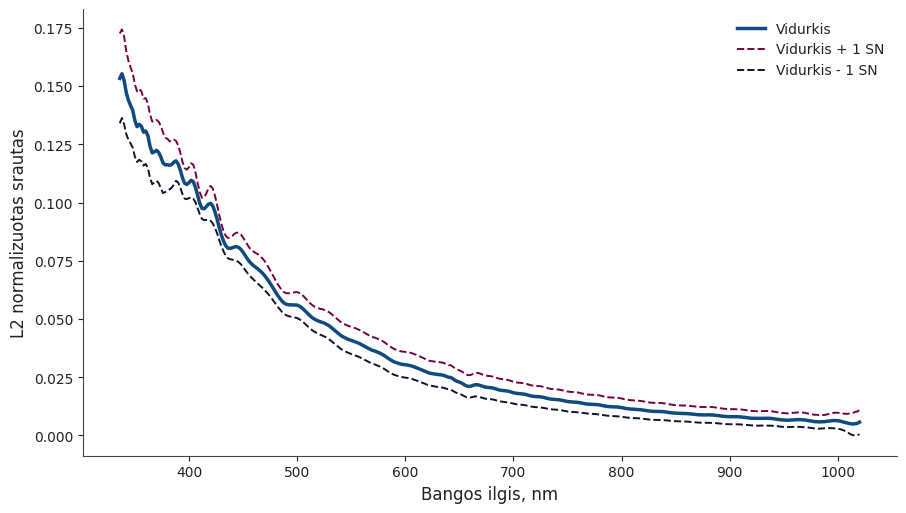

In [24]:
mean_overall = X_main.mean(axis=0)
std_overall = X_main.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_overall, linewidth=2.5, color=COLOR_PRIMARY, label="Vidurkis")
ax.plot(wavelengths, mean_overall + std_overall, linestyle="--", linewidth=1.4, color=COLOR_SECONDARY, label="Vidurkis + 1 SN")
ax.plot(wavelengths, mean_overall - std_overall, linestyle="--", linewidth=1.4, color=COLOR_DARK, label="Vidurkis - 1 SN")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 8. Class-wise mean spectra and mean differences

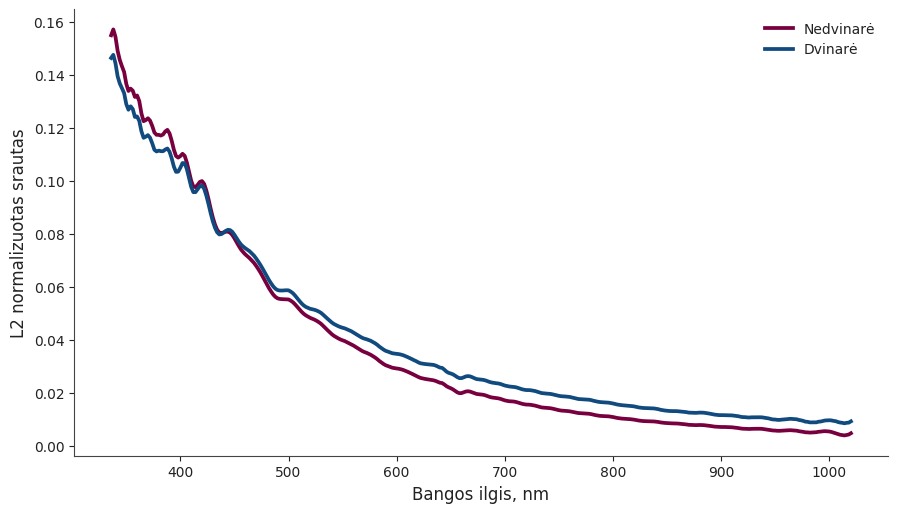

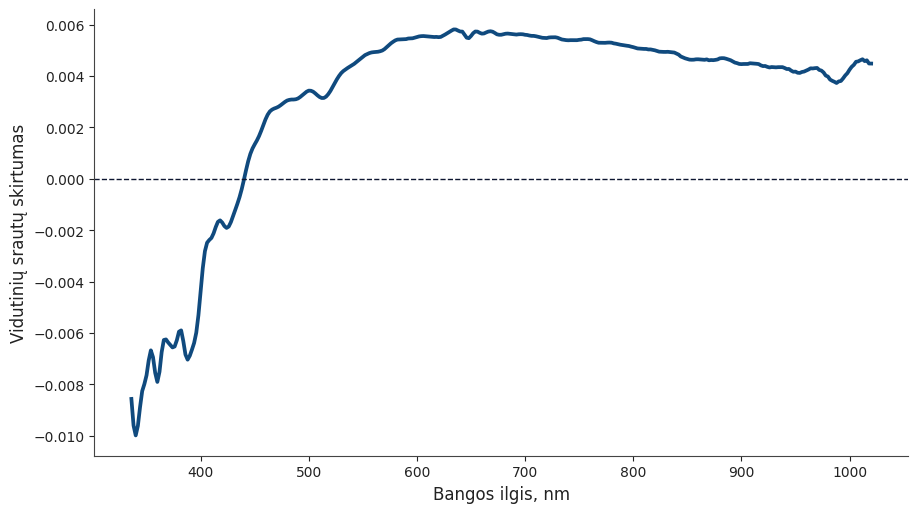

In [25]:
class_mean_spectra = pd.DataFrame({
    "wavelength": wavelengths,
    "mean_non_binary_raw": mean_nonbinary_raw,
    "mean_binary_raw": mean_binary_raw,
    "mean_non_binary_l2": mean_nonbinary_l2,
    "mean_binary_l2": mean_binary_l2,
    "difference_binary_minus_non_binary_l2": diff_l2,
})

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_nonbinary_main, linewidth=2.7, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_binary_main, linewidth=2.7, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, diff_l2, linewidth=2.7, color=COLOR_PRIMARY)
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinių srautų skirtumas")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 9. Wavelength-wise summary statistics

In [26]:
wavelength_stats = pd.DataFrame({
    "wavelength": wavelengths,
    "mean_overall_main": mean_overall,
    "std_overall_main": std_overall,
    "mean_binary_l2": mean_binary_l2,
    "mean_non_binary_l2": mean_nonbinary_l2,
    "abs_mean_diff_l2": np.abs(diff_l2),
})

top_pos_l2 = class_mean_spectra.sort_values("difference_binary_minus_non_binary_l2", ascending=False).head(10)
top_neg_l2 = class_mean_spectra.sort_values("difference_binary_minus_non_binary_l2", ascending=True).head(10)

top_wavelength_differences = pd.concat([
    top_pos_l2.assign(direction="binary_higher"),
    top_neg_l2.assign(direction="non_binary_higher"),
], ignore_index=True)

print("Top wavelengths where binary mean is higher (L2):")
display(top_pos_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Top wavelengths where non-binary mean is higher (L2):")
display(top_neg_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])


Top wavelengths where binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
149,634.0,0.005810
150,636.0,0.005807
151,638.0,0.005766
148,632.0,0.005764
166,668.0,0.005739
159,654.0,0.005729
152,640.0,0.005729
165,666.0,0.005726
153,642.0,0.005726
160,656.0,0.005725


Top wavelengths where non-binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
2,340.0,-0.009984
3,342.0,-0.009609
1,338.0,-0.009598
4,344.0,-0.008884
0,336.0,-0.008564
5,346.0,-0.008257
6,348.0,-0.007987
12,360.0,-0.007904
7,350.0,-0.007645
11,358.0,-0.007548


  ## 10. Correlation structure across wavelengths

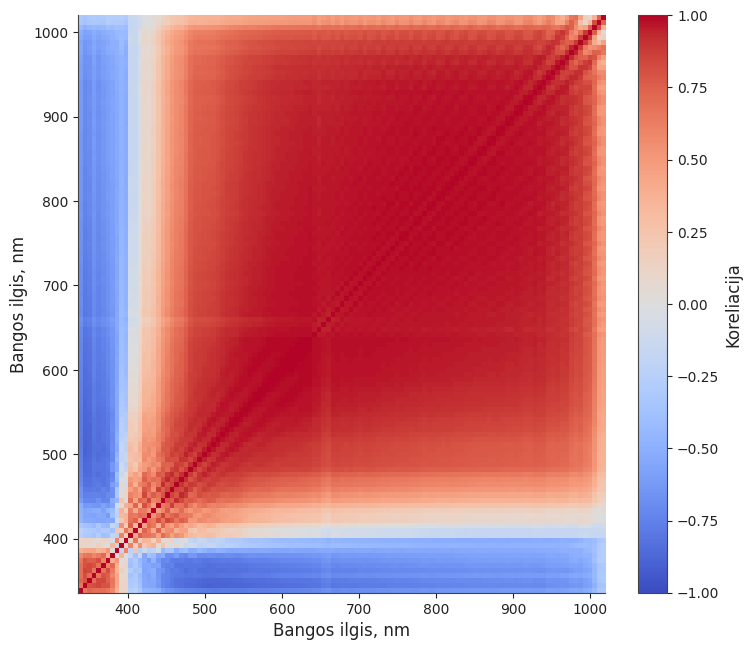

In [27]:
corr_wavelength = np.corrcoef(X_main, rowvar=False)
corr_wavelength_plot = corr_wavelength[::CORR_PLOT_STEP, ::CORR_PLOT_STEP]
wavelengths_plot = wavelengths[::CORR_PLOT_STEP]

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(
    corr_wavelength_plot,
    aspect="auto",
    origin="lower",
    interpolation="none",
    extent=[
        wavelengths_plot.min(),
        wavelengths_plot.max(),
        wavelengths_plot.min(),
        wavelengths_plot.max(),
    ],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Koreliacija")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Bangos ilgis, nm")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 11. First and second derivatives

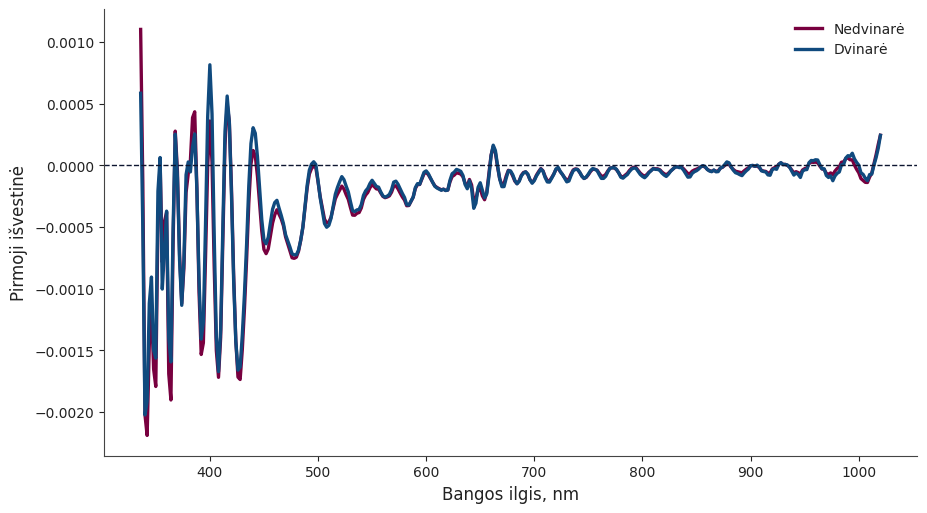

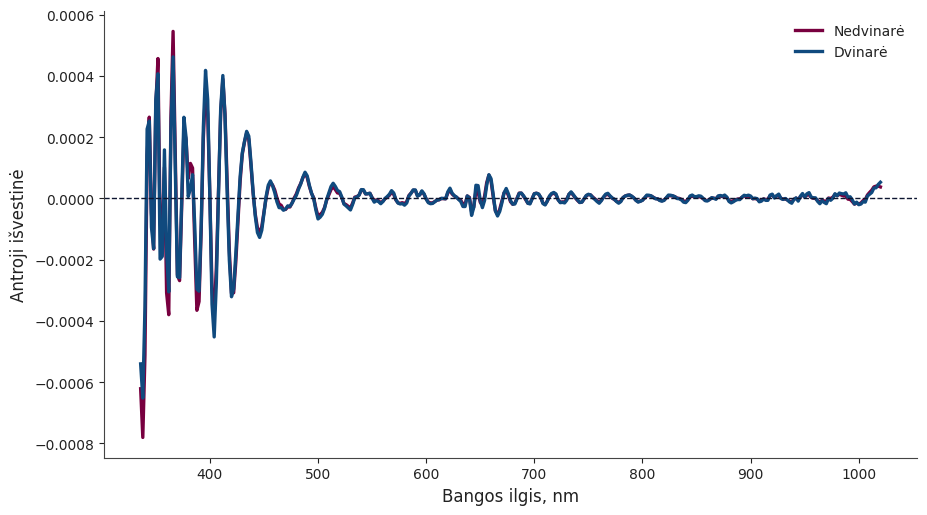

In [28]:
D1 = compute_first_derivative(X_main, wavelengths)
D2 = compute_second_derivative(X_main, wavelengths)

mean_d1_binary = D1[idx_binary].mean(axis=0)
mean_d1_nonbinary = D1[idx_nonbinary].mean(axis=0)

mean_d2_binary = D2[idx_binary].mean(axis=0)
mean_d2_nonbinary = D2[idx_nonbinary].mean(axis=0)

derivative_summary_by_class = pd.DataFrame({
    "wavelength": wavelengths,
    "mean_d1_non_binary": mean_d1_nonbinary,
    "mean_d1_binary": mean_d1_binary,
    "mean_d2_non_binary": mean_d2_nonbinary,
    "mean_d2_binary": mean_d2_binary,
})

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_d1_nonbinary, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_d1_binary, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Pirmoji išvestinė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_d2_nonbinary, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_d2_binary, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Antroji išvestinė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 12. Simple global descriptors per spectrum

In [29]:
area_under_curve = np.trapz(X_main, wavelengths, axis=1)
roughness_d1 = np.trapz(D1 ** 2, wavelengths, axis=1)
roughness_d2 = np.trapz(D2 ** 2, wavelengths, axis=1)

spectrum_descriptors = pd.DataFrame({
    "source_id": source_ids,
    "y": y,
    "class_name": pd.Series(y).map({0: "non_binary", 1: "binary"}),
    "auc": area_under_curve,
    "roughness_d1": roughness_d1,
    "roughness_d2": roughness_d2,
})

display(spectrum_descriptors.head())

global_descriptors_summary = (
    spectrum_descriptors
    .groupby("class_name")[["auc", "roughness_d1", "roughness_d2"]]
    .agg(["mean", "std", "median"])
)

display(global_descriptors_summary)


,source_id,y,class_name,auc,roughness_d1,roughness_d2
0,1792620565667968,0,non_binary,24.608996,0.000653,0.000102
1,6052403489630720,0,non_binary,24.144017,0.000392,0.000048
2,10844075163628928,0,non_binary,28.351815,0.000502,0.000059
3,11015044926034816,0,non_binary,26.794635,0.001251,0.000164
4,11963171843658240,0,non_binary,27.884115,0.000695,0.000118


auc                      roughness_d1                      \
                 mean       std     median         mean       std    median   
class_name                                                                    
binary      27.493734  2.082781  27.511350     0.000864  0.001006  0.000546   
non_binary  25.333139  1.532462  25.076674     0.000719  0.000789  0.000457   

           roughness_d2                      
                   mean       std    median  
class_name                                   
binary         0.000134  0.000184  0.000074  
non_binary     0.000107  0.000150  0.000058

  ## 13. Save main table outputs

In [30]:
dataset_summary.to_csv(OUT_DIR / "dataset_summary.csv", index=False)
class_mean_spectra.to_csv(OUT_DIR / "class_mean_spectra.csv", index=False)
derivative_summary_by_class.to_csv(OUT_DIR / "derivative_summary_by_class.csv", index=False)
top_wavelength_differences.to_csv(OUT_DIR / "top_wavelength_differences.csv", index=False)
spectrum_descriptors.to_csv(OUT_DIR / "spectrum_descriptors.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)


Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\01_initial_data_exploration


  ## 14. Save figures

In [31]:
# Example spectra
fig, ax = plt.subplots(figsize=(10.5, 5.8))

for idx in plot_nonbinary:
    ax.plot(wavelengths, X_main[idx], alpha=0.18, linewidth=1.0, color=COLOR_SECONDARY)
for idx in plot_binary:
    ax.plot(wavelengths, X_main[idx], alpha=0.18, linewidth=1.0, color=COLOR_PRIMARY)

ax.plot(wavelengths, mean_nonbinary_main, linewidth=2.8, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_binary_main, linewidth=2.8, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_example_spectra.svg")

# Overall mean and SD
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_overall, linewidth=2.5, color=COLOR_PRIMARY, label="Vidurkis")
ax.plot(wavelengths, mean_overall + std_overall, linestyle="--", linewidth=1.4, color=COLOR_SECONDARY, label="Vidurkis + 1 SN")
ax.plot(wavelengths, mean_overall - std_overall, linestyle="--", linewidth=1.4, color=COLOR_DARK, label="Vidurkis - 1 SN")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_mean_std_overall.svg")

# Class means
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_nonbinary_main, linewidth=2.7, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_binary_main, linewidth=2.7, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas" if MAIN_REPRESENTATION == "l2" else "Srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_spectra.svg")

# Mean difference
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, diff_l2, linewidth=2.7, color=COLOR_PRIMARY)
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinių srautų skirtumas")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_difference_l2.svg")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(
    corr_wavelength_plot,
    aspect="auto",
    origin="lower",
    interpolation="none",
    extent=[
        wavelengths_plot.min(),
        wavelengths_plot.max(),
        wavelengths_plot.min(),
        wavelengths_plot.max(),
    ],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Koreliacija")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Bangos ilgis, nm")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_correlation_heatmap.svg")

# First derivative
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_d1_nonbinary, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_d1_binary, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Pirmoji išvestinė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_first_derivative_means.svg")

# Second derivative
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(wavelengths, mean_d2_nonbinary, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_d2_binary, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")
ax.axhline(0, linestyle="--", linewidth=1.0, color=COLOR_DARK)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Antroji išvestinė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_second_derivative_means.svg")

print("Saved figure outputs to:", OUT_DIR)


Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\01_initial_data_exploration


  ## 15. Initial functional insights

In [32]:
print("Top wavelengths where binary mean is higher (L2):")
display(top_pos_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Top wavelengths where non-binary mean is higher (L2):")
display(top_neg_l2[["wavelength", "difference_binary_minus_non_binary_l2"]])

print("Global descriptor summary by class:")
display(global_descriptors_summary)

Top wavelengths where binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
149,634.0,0.005810
150,636.0,0.005807
151,638.0,0.005766
148,632.0,0.005764
166,668.0,0.005739
159,654.0,0.005729
152,640.0,0.005729
165,666.0,0.005726
153,642.0,0.005726
160,656.0,0.005725


Top wavelengths where non-binary mean is higher (L2):


,wavelength,difference_binary_minus_non_binary_l2
2,340.0,-0.009984
3,342.0,-0.009609
1,338.0,-0.009598
4,344.0,-0.008884
0,336.0,-0.008564
5,346.0,-0.008257
6,348.0,-0.007987
12,360.0,-0.007904
7,350.0,-0.007645
11,358.0,-0.007548


Global descriptor summary by class:


auc                      roughness_d1                      \
                 mean       std     median         mean       std    median   
class_name                                                                    
binary      27.493734  2.082781  27.511350     0.000864  0.001006  0.000546   
non_binary  25.333139  1.532462  25.076674     0.000719  0.000789  0.000457   

           roughness_d2                      
                   mean       std    median  
class_name                                   
binary         0.000134  0.000184  0.000074  
non_binary     0.000107  0.000150  0.000058